# DBSCAN Clustering Visualization for German Cities

This notebook visualizes the results of DBSCAN spatial clustering on German cities (>50k population), showing cluster distributions, noise points, and geographic patterns.

## 1. Import Required Libraries

In [41]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add the project root to path for imports
project_root = Path('.').resolve().parent
sys.path.insert(0, str(project_root))

from core.spatial import (
    cluster_cities, 
    describe_clusters, 
    cluster_centroids, 
    split_clustered_cities,
    EARTH_RADIUS_KM
)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load and Prepare Data

In [42]:
# Load city data
from core.data import find_cities_file

cities_file = find_cities_file()
print(f"📍 Loading cities from: {cities_file}")

# Read raw data - file format: "City, latitude, longitude"
raw_data = []
with open(cities_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            # Split from the right to handle city names with commas
            parts = line.rsplit(',', 2)
            if len(parts) == 3:
                city_name = parts[0].strip()
                try:
                    latitude = float(parts[1].strip())
                    longitude = float(parts[2].strip())
                    raw_data.append({'city_name': city_name, 'latitude': latitude, 'longitude': longitude})
                except ValueError:
                    print(f"Warning: Could not parse {line}")

cities = pd.DataFrame(raw_data)

# Display basic information
print(f"\n✓ Loaded {len(cities)} cities")
print(f"\nFirst 5 cities:")
print(cities.head())

print(f"\n📊 Data Summary:")
print(f"  Latitude range: [{cities['latitude'].min():.2f}, {cities['latitude'].max():.2f}]")
print(f"  Longitude range: [{cities['longitude'].min():.2f}, {cities['longitude'].max():.2f}]")
print(f"  Missing values: {cities.isnull().sum().sum()}")

# Display statistics
print(f"\n📈 Coordinate Statistics:")
print(cities[['latitude', 'longitude']].describe())

📍 Loading cities from: c:\Users\aksha\Downloads\Documents\FAU\project seminar\code\data\cities_de_50k.txt

✓ Loaded 236 cities

First 5 cities:
              city_name  latitude  longitude
0                Aachen  50.77664    6.08342
1                 Aalen  48.83777   10.09330
2                 Ahlen  51.76338    7.88870
3  Alt-Hohenschönhausen  52.54608   13.50130
4                Altona  53.55000    9.93333

📊 Data Summary:
  Latitude range: [47.66, 54.79]
  Longitude range: [6.08, 14.99]
  Missing values: 0

📈 Coordinate Statistics:
         latitude   longitude
count  236.000000  236.000000
mean    51.290376    9.456877
std      1.550620    2.349114
min     47.656890    6.083420
25%     50.538040    7.290093
50%     51.432325    8.893680
75%     52.434447   11.045900
max     54.788050   14.988530


## 3. Perform DBSCAN Clustering

In [43]:
# DBSCAN clustering parameters
eps_km = 40 # Neighborhood radius in kilometers
min_samples = 2  # Minimum points to form a cluster

print(f"🔧 DBSCAN Parameters:")
print(f"  eps_km (neighborhood radius): {eps_km} km")
print(f"  min_samples (min cluster size): {min_samples}")
print(f"\nRunning DBSCAN clustering...")

# Perform clustering
labels = cluster_cities(cities, eps_km=eps_km, min_samples=min_samples)

# Analyze results
profile = describe_clusters(labels)
print(f"\n✓ Clustering Complete!")
print(f"\n📊 Clustering Results:")
print(f"  Clusters found: {profile.cluster_count}")
print(f"  Noise points: {profile.noise_count}")
print(f"  Total cities: {len(cities)}")
print(f"  Coverage: {(len(cities) - profile.noise_count) / len(cities) * 100:.1f}%")

# Get centroids
centroids = cluster_centroids(cities, labels)
print(f"\n🎯 Cluster Centroids: {len(centroids)}")
print(centroids.head(10))

# Print cluster sizes
print(f"\n📋 Cluster Sizes:")
for cluster_id, size in sorted(profile.cluster_sizes.items()):
    print(f"  Cluster {cluster_id:2d}: {size:3d} cities")

🔧 DBSCAN Parameters:
  eps_km (neighborhood radius): 40 km
  min_samples (min cluster size): 2

Running DBSCAN clustering...

✓ Clustering Complete!

📊 Clustering Results:
  Clusters found: 17
  Noise points: 24
  Total cities: 236
  Coverage: 89.8%

🎯 Cluster Centroids: 17
   cluster_label   latitude  longitude  city_count
0              0  51.491281   7.516489          95
1              1  49.340788   8.877235          37
2              2  52.495032  13.376407          30
3              3  53.540286  10.066015          15
4              4  49.604965  10.993645           4
5              5  48.144820  11.595670           2
6              6  53.089103   8.550957           3
7              7  53.656483   8.459500           3
8              8  50.832421  11.941656           7
9              9  47.658610   9.325680           2

📋 Cluster Sizes:
  Cluster  0:  95 cities
  Cluster  1:  37 cities
  Cluster  2:  30 cities
  Cluster  3:  15 cities
  Cluster  4:   4 cities
  Cluster  5:   2 cit

## 4. Visualize Clusters on a Map

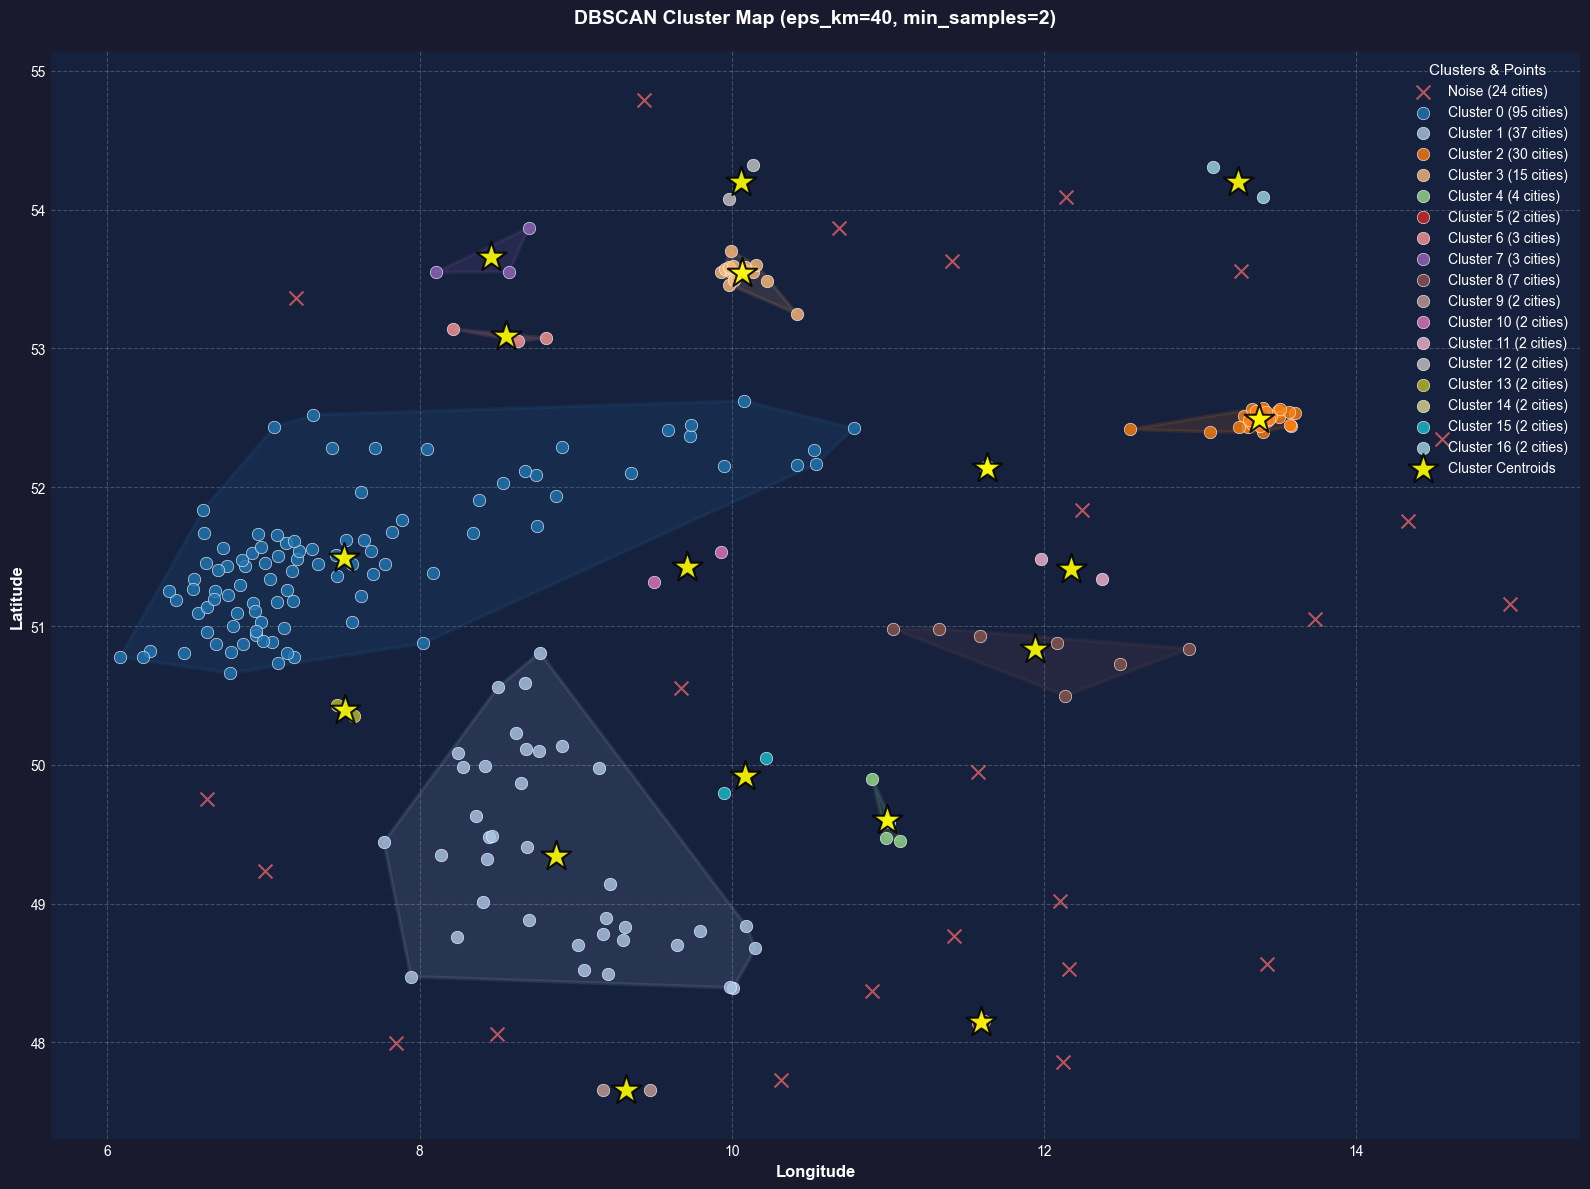

✓ Map visualization complete! (17 centroids plotted)


In [45]:
# Create figure with dark background (matching run.py style)
fig, ax = plt.subplots(figsize=(16, 12), facecolor="#1a1a2e")
ax.set_facecolor("#16213e")

# Get unique labels
unique_labels = sorted(set(labels))

# Define color map for clusters
if len(unique_labels) <= 20:
    cmap = plt.colormaps.get_cmap("tab20")
else:
    cmap = plt.colormaps.get_cmap("hsv")

# Helper function to compute convex hull (cluster boundary)
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon

def get_cluster_boundary(points):
    """Get convex hull vertices for a set of points"""
    if len(points) < 3:
        return None
    try:
        hull = ConvexHull(points)
        return points[hull.vertices]
    except:
        return None

# Plot each cluster with different color and contour
for label in unique_labels:
    if label == -1:
        # Noise points - red with 'x' marker
        mask = labels == label
        ax.scatter(
            cities.loc[mask, "longitude"],
            cities.loc[mask, "latitude"],
            c="#ff6b6b", 
            marker="x", 
            s=100, 
            linewidths=1.5,
            alpha=0.7,
            label=f"Noise ({np.sum(mask)} cities)",
            zorder=3
        )
    else:
        # Clustered points - different color per cluster
        mask = labels == label
        color = cmap(label / max(1, len(unique_labels) - 2))
        
        # Get cluster points
        cluster_points = cities.loc[mask, ["longitude", "latitude"]].values
        
        # Draw cluster boundary (convex hull with semi-transparent fill)
        if len(cluster_points) >= 3:
            boundary_points = get_cluster_boundary(cluster_points)
            if boundary_points is not None:
                polygon = Polygon(
                    boundary_points,
                    alpha=0.12,
                    facecolor=color,
                    edgecolor=color,
                    linewidth=2.5,
                    linestyle="-",
                    zorder=1
                )
                ax.add_patch(polygon)
        
        # Plot cluster points
        ax.scatter(
            cities.loc[mask, "longitude"],
            cities.loc[mask, "latitude"],
            c=[color],
            marker="o",
            s=80,
            alpha=0.8,
            edgecolors="white",
            linewidths=0.5,
            label=f"Cluster {label} ({np.sum(mask)} cities)",
            zorder=2
        )

# Plot centroids as yellow stars
centroids_df = cluster_centroids(cities, labels)
ax.scatter(
    centroids_df["longitude"],
    centroids_df["latitude"],
    c="yellow",
    marker="*",
    s=500,
    edgecolors="black",
    linewidths=1.5,
    label="Cluster Centroids",
    zorder=4,
    alpha=0.9
)

# Add labels and legend
ax.set_xlabel("Longitude", fontweight="bold", fontsize=12, color="white")
ax.set_ylabel("Latitude", fontweight="bold", fontsize=12, color="white")
ax.set_title(f"DBSCAN Cluster Map (eps_km={eps_km}, min_samples={min_samples})", 
             fontweight="bold", fontsize=14, color="white", pad=20)

# Style legend
legend = ax.legend(loc="upper right", framealpha=0.95, fontsize=10, 
                   title="Clusters & Points", title_fontsize=11, 
                   edgecolor="white", facecolor="#2c3e50")
legend.get_title().set_color("white")
for text in legend.get_texts():
    text.set_color("white")

# Adjust tick colors for dark theme
ax.tick_params(axis="x", colors="white", labelsize=10)
ax.tick_params(axis="y", colors="white", labelsize=10)
ax.grid(True, alpha=0.2, color="white", linestyle="--")

plt.tight_layout()
plt.show()

print(f"✓ Map visualization complete! ({len(centroids_df)} centroids plotted)")

## 5. Visualize Cluster Statistics

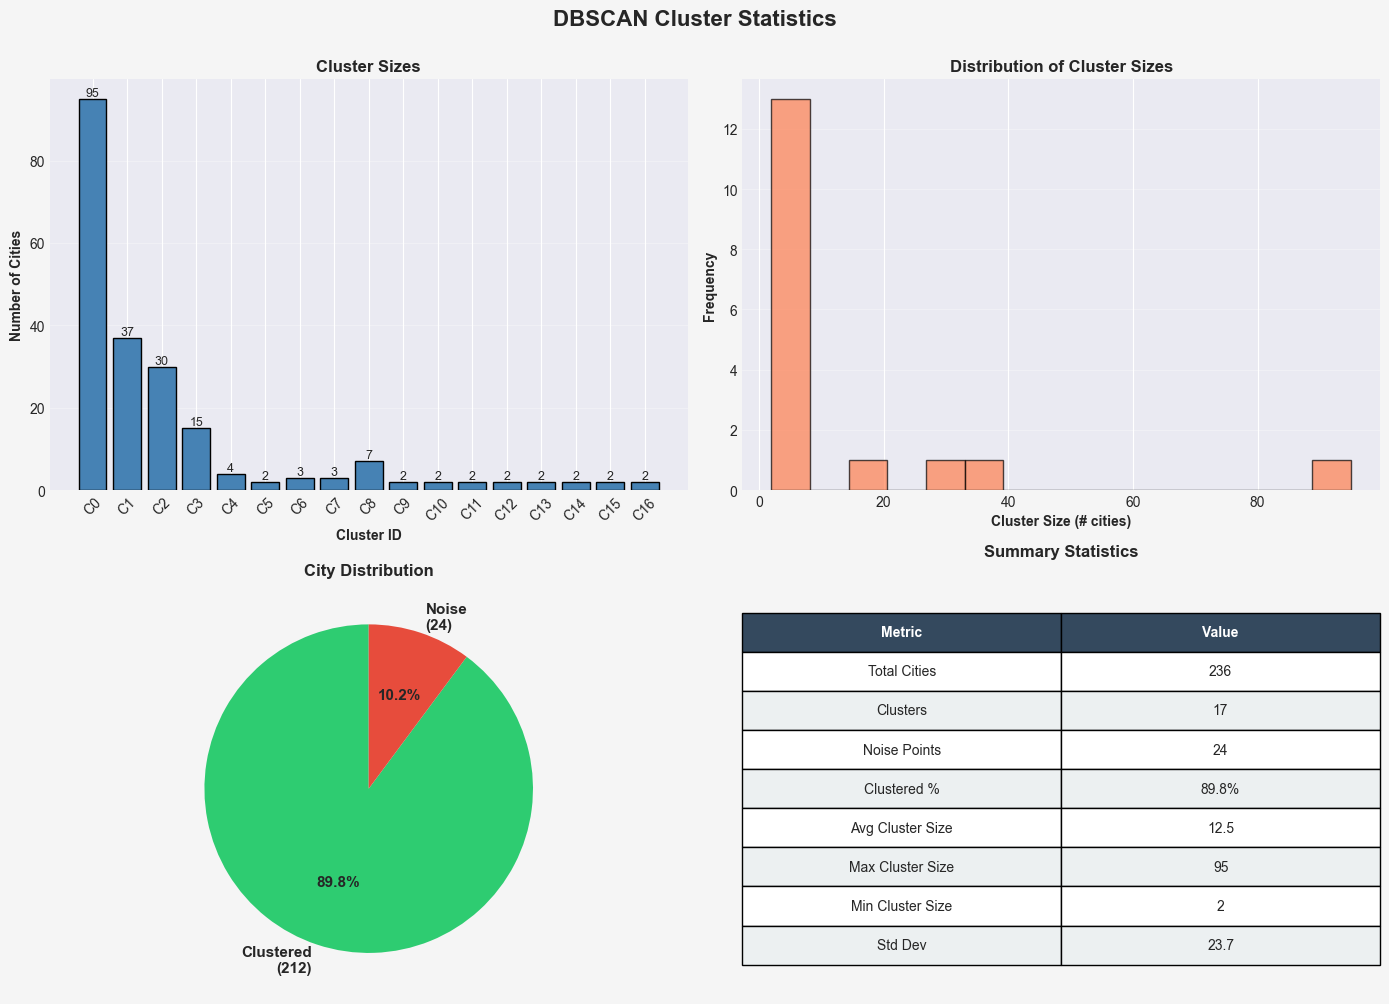

✓ Statistics visualization complete!


In [40]:
# Prepare data for statistics
cluster_stats = pd.DataFrame([
    {"Cluster": f"Cluster {cid}", "Size": size}
    for cid, size in sorted(profile.cluster_sizes.items())
])

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor="#f5f5f5")
fig.suptitle("DBSCAN Cluster Statistics", fontsize=16, fontweight="bold", y=1.00)

# 1. Bar chart of cluster sizes
ax1 = axes[0, 0]
bars = ax1.bar(range(len(cluster_stats)), cluster_stats["Size"], color="steelblue", edgecolor="black")
ax1.set_xlabel("Cluster ID", fontweight="bold")
ax1.set_ylabel("Number of Cities", fontweight="bold")
ax1.set_title("Cluster Sizes", fontweight="bold")
ax1.set_xticks(range(len(cluster_stats)))
ax1.set_xticklabels([f"C{i}" for i in range(len(cluster_stats))], rotation=45)
ax1.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

# 2. Histogram of cluster sizes
ax2 = axes[0, 1]
ax2.hist(cluster_stats["Size"], bins=15, color="coral", edgecolor="black", alpha=0.7)
ax2.set_xlabel("Cluster Size (# cities)", fontweight="bold")
ax2.set_ylabel("Frequency", fontweight="bold")
ax2.set_title("Distribution of Cluster Sizes", fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

# 3. Pie chart: Clustered vs Noise
ax3 = axes[1, 0]
sizes = [len(cities) - profile.noise_count, profile.noise_count]
pie_labels = [f"Clustered\n({sizes[0]})", f"Noise\n({sizes[1]})"]
colors = ["#2ecc71", "#e74c3c"]
ax3.pie(sizes, labels=pie_labels, colors=colors, autopct="%1.1f%%", 
        startangle=90, textprops={"fontsize": 11, "fontweight": "bold"})
ax3.set_title("City Distribution", fontweight="bold")

# 4. Summary statistics table
ax4 = axes[1, 1]
ax4.axis("tight")
ax4.axis("off")

summary_data = [
    ["Metric", "Value"],
    ["Total Cities", f"{len(cities)}"],
    ["Clusters", f"{profile.cluster_count}"],
    ["Noise Points", f"{profile.noise_count}"],
    ["Clustered %", f"{(len(cities) - profile.noise_count) / len(cities) * 100:.1f}%"],
    ["Avg Cluster Size", f"{cluster_stats['Size'].mean():.1f}"],
    ["Max Cluster Size", f"{cluster_stats['Size'].max()}"],
    ["Min Cluster Size", f"{cluster_stats['Size'].min()}"],
    ["Std Dev", f"{cluster_stats['Size'].std():.1f}"],
]

table = ax4.table(cellText=summary_data, cellLoc="center", loc="center",
                 colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(2):
    table[(0, i)].set_facecolor("#34495e")
    table[(0, i)].set_text_props(weight="bold", color="white")

# Style data rows
for i in range(1, len(summary_data)):
    for j in range(2):
        if i % 2 == 0:
            table[(i, j)].set_facecolor("#ecf0f1")
        else:
            table[(i, j)].set_facecolor("#ffffff")

ax4.set_title("Summary Statistics", fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

print("✓ Statistics visualization complete!")

## 6. Analyze Noise Points

📊 Noise Point Analysis

Clustered cities: 203
Noise cities: 33

🔍 Noise Cities Details:
               city_name  latitude  longitude  cluster_label
                Augsburg  48.37154   10.89851             -1
                 Bamberg  49.89873   10.90067             -1
                Bayreuth  49.94782   11.57893             -1
Brandenburg an der Havel  52.41667   12.55000             -1
                 Cottbus  51.75769   14.32888             -1
                Cuxhaven  53.86828    8.69902             -1
                  Dessau  51.83864   12.24555             -1
                 Dresden  51.05089   13.73832             -1
                   Emden  53.36592    7.20846             -1
               Flensburg  54.78805    9.43722             -1
        Frankfurt (Oder)  52.34714   14.55062             -1
                Freiburg  47.99590    7.85222             -1
                   Fulda  50.55162    9.67518             -1
                 Görlitz  51.15518   14.98853             

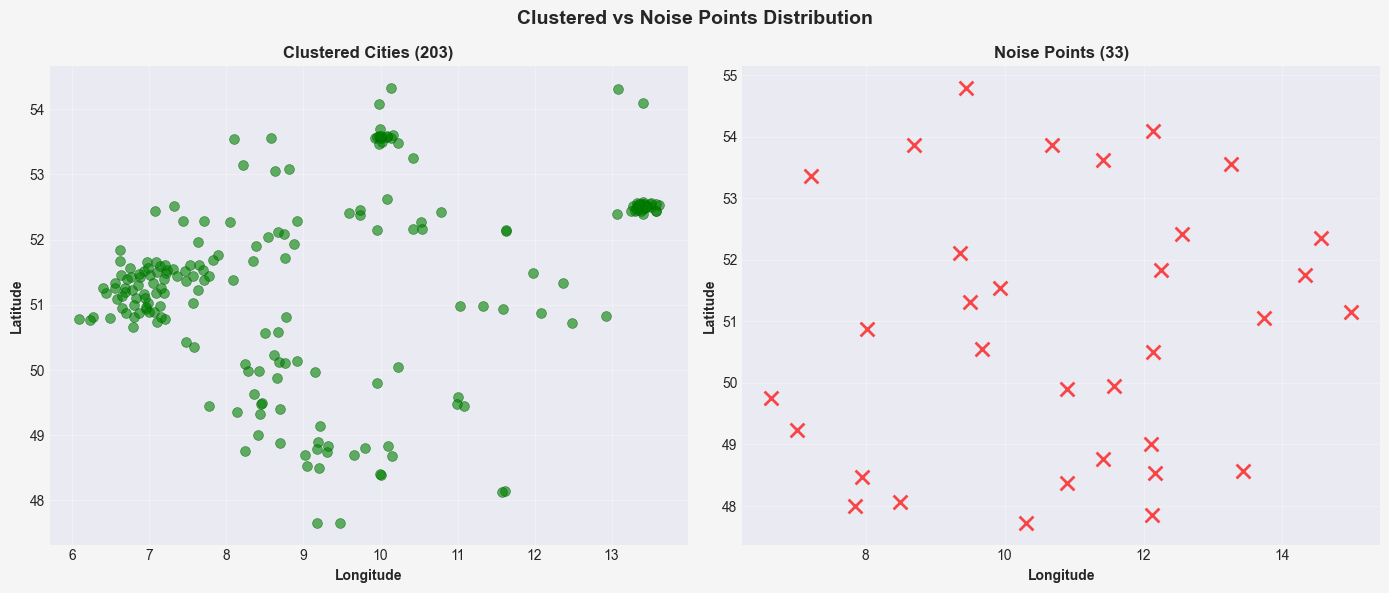


✓ Noise analysis complete!


In [21]:
# Split data into clustered and noise
clustered, noise = split_clustered_cities(cities, labels)

print(f"📊 Noise Point Analysis")
print(f"{'='*50}")
print(f"\nClustered cities: {len(clustered)}")
print(f"Noise cities: {len(noise)}")

if len(noise) > 0:
    print(f"\n🔍 Noise Cities Details:")
    print(noise.to_string(index=False))
    
    print(f"\n📍 Noise Geographic Distribution:")
    print(f"  Latitude range: [{noise['latitude'].min():.2f}, {noise['latitude'].max():.2f}]")
    print(f"  Longitude range: [{noise['longitude'].min():.2f}, {noise['longitude'].max():.2f}]")
    
    print(f"\n📈 Noise Statistics:")
    print(noise[['latitude', 'longitude']].describe())
else:
    print(f"\n✓ No noise points detected!")

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="#f5f5f5")
fig.suptitle("Clustered vs Noise Points Distribution", fontsize=14, fontweight="bold")

# Left: Clustered cities
ax1 = axes[0]
ax1.scatter(clustered["longitude"], clustered["latitude"], 
           c="green", alpha=0.6, s=50, edgecolors="darkgreen", linewidth=0.5)
ax1.set_xlabel("Longitude", fontweight="bold")
ax1.set_ylabel("Latitude", fontweight="bold")
ax1.set_title(f"Clustered Cities ({len(clustered)})", fontweight="bold")
ax1.grid(True, alpha=0.3)

# Right: Noise points (if any)
ax2 = axes[1]
if len(noise) > 0:
    ax2.scatter(noise["longitude"], noise["latitude"], 
               c="red", alpha=0.7, s=100, marker="x", linewidth=2)
    ax2.set_title(f"Noise Points ({len(noise)})", fontweight="bold")
else:
    ax2.text(0.5, 0.5, "No noise points", ha="center", va="center", 
            fontsize=14, transform=ax2.transAxes, color="gray")
    ax2.set_title("Noise Points (0)", fontweight="bold")

ax2.set_xlabel("Longitude", fontweight="bold")
ax2.set_ylabel("Latitude", fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Noise analysis complete!")

## Summary: Key Insights

In [22]:
print("""
╔════════════════════════════════════════════════════════════════════════════╗
║                    DBSCAN CLUSTERING SUMMARY REPORT                       ║
╚════════════════════════════════════════════════════════════════════════════╝

📌 PARAMETERS:
   • eps_km (search radius): {} km
   • min_samples (min cluster size): {}
   • Distance metric: Haversine (great-circle distance)

📊 RESULTS:
   • Total cities analyzed: {}
   • Clusters formed: {}
   • Noise points: {}
   • Clustering coverage: {:.1f}%

🎯 CLUSTER INSIGHTS:
   • Average cluster size: {:.1f} cities
   • Largest cluster: {} cities
   • Smallest cluster: {} cities
   • Size standard deviation: {:.1f}

📍 NOISE ANALYSIS:
   • Isolated cities: {}
   • These cities will require separate tower placement
   • They represent {} of all cities

💡 INTERPRETATION:
   • The {} clustered groups suggest {} economically efficient tower locations
   • Noise points ({}) will need sparse radius optimization
   • Centroids (shown as yellow stars) mark optimal dense tower positions

📝 NEXT STEPS:
   1. Run radius selection optimization on clustered and noise groups
   2. Generate candidate tower locations at centroids
   3. Execute MILP solver to select optimal tower subset
""".format(
    eps_km,
    min_samples,
    len(cities),
    profile.cluster_count,
    profile.noise_count,
    (len(cities) - profile.noise_count) / len(cities) * 100,
    cluster_stats['Size'].mean(),
    cluster_stats['Size'].max(),
    cluster_stats['Size'].min(),
    cluster_stats['Size'].std(),
    len(noise),
    len(noise) / len(cities) * 100,
    profile.cluster_count,
    profile.cluster_count,
    len(noise)
))

print("✓ Visualization notebook complete! Ready for next phase: radius selection.")


╔════════════════════════════════════════════════════════════════════════════╗
║                    DBSCAN CLUSTERING SUMMARY REPORT                       ║
╚════════════════════════════════════════════════════════════════════════════╝

📌 PARAMETERS:
   • eps_km (search radius): 35.0 km
   • min_samples (min cluster size): 2
   • Distance metric: Haversine (great-circle distance)

📊 RESULTS:
   • Total cities analyzed: 236
   • Clusters formed: 19
   • Noise points: 33
   • Clustering coverage: 86.0%

🎯 CLUSTER INSIGHTS:
   • Average cluster size: 10.7 cities
   • Largest cluster: 79 cities
   • Smallest cluster: 2 cities
   • Size standard deviation: 18.9

📍 NOISE ANALYSIS:
   • Isolated cities: 33
   • These cities will require separate tower placement
   • They represent 13.983050847457626 of all cities

💡 INTERPRETATION:
   • The 19 clustered groups suggest 19 economically efficient tower locations
   • Noise points (33) will need sparse radius optimization
   • Centroids (shown a